In [1]:
import pandas as pd
import pandas as pd
import os
import pickle
import torch
import torch.nn.functional as F


In [2]:
df = pd.read_pickle('./1789_2023_MAPPINGS_N_N1_with_similarity.pkl')


In [4]:
# filter where year_N is between 1963 and 1988
df_1963_1988 = df[(df['year_N'] >= 1963) & (df['year_N'] <= 1988)]

df_1963_1988

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity
460031,1987,1989,1987,1989,100.09,01051900,0.827414,0.312500,0.534351,0.695125,"Live birds: Chickens, ducks, geese, guineas, a...","Live ducks, geese, turkeys and guineas, weighi...","live birds: chickens, ducks, geese, guineas, a...","live ducks, geese, turkeys and guineas, weighi...",01059900,"Live ducks, geese, turkeys and guineas, weighi...",0.812394
460032,1987,1989,1987,1989,100.04,98010090,0.579781,0.178571,0.330709,0.474632,"Animals, domesticated, straying across the bou...","00 3 Animals, domesticated, straying across the","animals, domesticated, straying across the bou...","00 3 animals, domesticated, straying across the",01019030,Mules and hinnies imported for immediate slaug...,0.507352
460033,1987,1989,1987,1989,100.01,43021915,0.584656,0.069444,0.295238,0.452672,"Animals (except black, silver, or platinum fox...","Tanned or dressed whole furskins of silver, bl...","animals (except black, silver, or platinum fox...","tanned or dressed whole furskins of silver, bl...",43021915,"Tanned or dressed whole furskins of silver, bl...",0.584656
460034,1987,1989,1987,1989,100.15,01060010,0.676930,0.100000,0.545455,0.548397,"Live birds: Pigeons, fancy or racing","Live birds, other than poultry","live birds: pigeons, fancy or racing","live birds, other than poultry",01063901,"Live birds, other than poultry, birds of prey ...",0.663006
460035,1987,1989,1987,1989,100.03,98130060,0.602685,0.105263,0.273333,0.470266,"Animals, domesticated, straying across the bou...",1/ Animals and poultry brought into the United,"animals, domesticated, straying across the bou...",1/ animals and poultry brought into the united,01019030,Mules and hinnies imported for immediate slaug...,0.511971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556009,1963,1965,1963,1965,955.01,955.01,1.000000,1.000000,0.998555,0.999855,"Whenever, in the respective 12-month period sp...","Whenever, in the respective 12-month period sp...","whenever, in the respective 12-month period sp...","whenever, in the respective 12-month period sp...",53039000,Jute and other textile bast fibers (excluding ...,0.485070
556010,1963,1965,1963,1965,950.1,950.07,0.918221,0.686567,0.834008,0.863469,"Whenever, in any 12-month period beginning Jul...","Whenever, in any 12-month period beginning Jul...","whenever, in any 12-month period beginning jul...","whenever, in any 12-month period beginning jul...",04012020,"Milk and cream, unconcentrated, unsweetened, f...",0.533794
556011,1963,1965,1963,1965,955.02,955.02,1.000000,1.000000,0.999351,0.999935,"Whenever, in the respective 12-month period sp...","Whenever, in the respective 12-month period sp...","whenever, in the respective 12-month period sp...","whenever, in the respective 12-month period sp...",52081120,"Woven cotton fabric, 85% or more cotton by wei...",0.573127
556012,1963,1965,1963,1965,955.05,955.05,0.886381,0.642857,0.718894,0.820927,"Whenever, in the respective 12-month period, e...","Whenever, in the respective 12-month period sp...","whenever, in the respective 12-month period, e...","whenever, in the respective 12-month period sp...",52081140,"Woven cotton fabric, 85% or more cotton by wei...",0.272125


Want to give the option to use HS6 code.

In [9]:
url = 'https://raw.githubusercontent.com/datasets/harmonized-system/main/data/harmonized-system.csv'
df = pd.read_csv(url, dtype=str)


# get all of the rows that have level 2
chapters = df[df['level'] == str(2)]
headings = df[df['level'] == str(4)]
subheadings = df[df['level'] == str(6)]


subheadings


,section,hscode,description,parent,level
2,I,010121,"Horses; live, pure-bred breeding animals",0101,6
3,I,010129,"Horses; live, other than pure-bred breeding an...",0101,6
4,I,010130,Asses; live,0101,6
5,I,010190,Mules and hinnies; live,0101,6
7,I,010221,"Cattle; live, pure-bred breeding animals",0102,6
...,...,...,...,...,...
6931,XXI,970531,Collections and collectors' pieces; of numisma...,9705,6
6932,XXI,970539,Collections and collectors' pieces; of numisma...,9705,6
6934,XXI,970610,Antiques; of an age exceeding 250 years,9706,6
6935,XXI,970690,Antiques; of an age exceeding 100 years but no...,9706,6


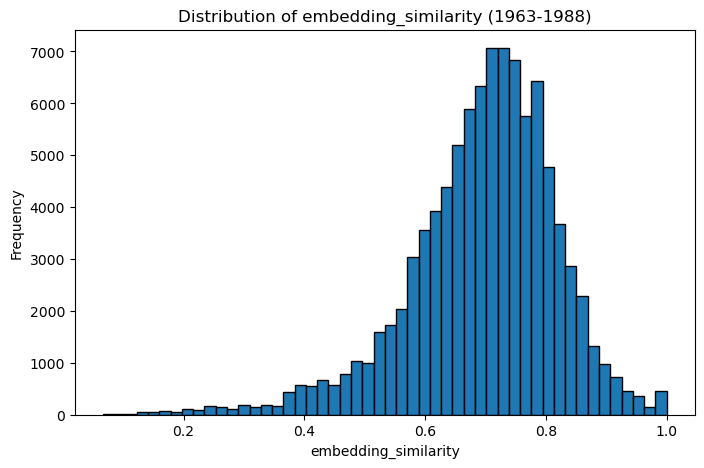

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_1963_1988['embedding_similarity'].hist(bins=50, edgecolor='black')
plt.title('Distribution of embedding_similarity (1963-1988)')
plt.xlabel('embedding_similarity')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

In [12]:
# how many rows with < 0.5

low_similarity = df_1963_1988[df_1963_1988['embedding_similarity'] < 0.5]
# sort low_similarity by Combined_Similarity in descending order
low_similarity = low_similarity.sort_values(by='embedding_similarity', ascending=False)

len(low_similarity), len(df_1963_1988)

# print proportion of rows with < 0.5
proportion_low_similarity = len(low_similarity) / len(df_1963_1988)
print(f'Proportion of rows with < 0.5: {proportion_low_similarity:.2%}')

Proportion of rows with < 0.5: 6.54%


In [13]:
import pandas as pd
import pickle
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

# Re-define your helper functions:
def setup_model_and_tokenizer():
    token = 'REDACTED_HF_TOKEN'
    model_name = 'sentence-transformers/all-mpnet-base-v2'
    tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
    model = AutoModel.from_pretrained(model_name, token=token)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    return tokenizer, model, device

def encode_text(texts, tokenizer, model, device):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    encoded_input = {k: v.to(device) for k, v in encoded_input.items()}
    with torch.no_grad():
        model_output = model(**encoded_input)
    token_embeddings = model_output.last_hidden_state
    attention_mask = encoded_input['attention_mask']
    mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    summed = torch.sum(token_embeddings * mask_expanded, dim=1)
    summed_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
    embeddings = summed / summed_mask
    embeddings = F.normalize(embeddings, p=2, dim=1)
    return embeddings

/Users/samirkadariya/opt/anaconda3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
import pandas as pd
import torch
import pickle
import os
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

# Re-use your setup and encoding functions
def setup_model_and_tokenizer():
    token = 'REDACTED_HF_TOKEN'
    model_name = 'sentence-transformers/all-mpnet-base-v2'
    tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
    model = AutoModel.from_pretrained(model_name, token=token)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    return tokenizer, model, device

def encode_text_batch(texts, tokenizer, model, device, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding batches"):
        batch = texts[i:i+batch_size]
        encoded_input = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        encoded_input = {k: v.to(device) for k, v in encoded_input.items()}
        with torch.no_grad():
            model_output = model(**encoded_input)
        token_embeddings = model_output.last_hidden_state
        attention_mask = encoded_input['attention_mask']
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        summed = torch.sum(token_embeddings * mask_expanded, dim=1)
        summed_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        embeddings = summed / summed_mask
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings.cpu())
    return torch.cat(all_embeddings, dim=0)

# Load the data from the GitHub URL
print("Loading HS code data...")
url = 'https://raw.githubusercontent.com/datasets/harmonized-system/main/data/harmonized-system.csv'
df = pd.read_csv(url, dtype=str)

# Extract chapters and headings
chapters = df[df['level'] == str(2)]
headings = df[df['level'] == str(4)]

# Setup the model and tokenizer
print("Setting up model and tokenizer...")
tokenizer, model, device = setup_model_and_tokenizer()

# Create output directory if it doesn't exist
os.makedirs('embeddings', exist_ok=True)

# Generate embeddings for chapters
print(f"Generating embeddings for {len(chapters)} chapters...")
chapter_descriptions = chapters['description'].tolist()
chapter_embeddings = encode_text_batch(chapter_descriptions, tokenizer, model, device)

# Save chapter embeddings
print("Saving chapter embeddings...")
with open('embeddings/chapters_embeddings.pkl', 'wb') as f:
    pickle.dump(chapter_embeddings, f)

# Generate embeddings for headings
print(f"Generating embeddings for {len(headings)} headings...")
heading_descriptions = headings['description'].tolist()
heading_embeddings = encode_text_batch(heading_descriptions, tokenizer, model, device)

# Save heading embeddings
print("Saving heading embeddings...")
with open('embeddings/headings_embeddings.pkl', 'wb') as f:
    pickle.dump(heading_embeddings, f)

print("Done! Created the following files:")
print("- embeddings/chapters_embeddings.pkl")
print("- embeddings/headings_embeddings.pkl")

# Optional: Verify the saved files
print("\nVerifying saved files:")
chapters_embeddings = pd.read_pickle('embeddings/chapters_embeddings.pkl')
headings_embeddings = pd.read_pickle('embeddings/headings_embeddings.pkl')
print(f"Chapters embeddings shape: {chapters_embeddings.shape}")
print(f"Headings embeddings shape: {headings_embeddings.shape}")

Loading HS code data...
Setting up model and tokenizer...
Generating embeddings for 97 chapters...


Encoding batches: 100%|██████████| 4/4 [00:02<00:00,  1.67it/s]


Saving chapter embeddings...
Generating embeddings for 1229 headings...


Encoding batches: 100%|██████████| 39/39 [00:16<00:00,  2.31it/s]


Saving heading embeddings...
Done! Created the following files:
- embeddings/chapters_embeddings.pkl
- embeddings/headings_embeddings.pkl

Verifying saved files:
Chapters embeddings shape: torch.Size([97, 768])
Headings embeddings shape: torch.Size([1229, 768])


In [17]:
# Add the embedding from subheadings_embeddings to each row in subheadings as a new column
subheadings['embedding'] = list(subheadings_embeddings)
subheadings

,section,hscode,description,parent,level,embedding
0,I,010121,"Horses; live, pure-bred breeding animals",0101,6,"[tensor(0.0160), tensor(0.0611), tensor(-0.006..."
1,I,010129,"Horses; live, other than pure-bred breeding an...",0101,6,"[tensor(0.0206), tensor(0.0791), tensor(-0.006..."
2,I,010130,Asses; live,0101,6,"[tensor(-0.0131), tensor(0.0570), tensor(-0.02..."
3,I,010190,Mules and hinnies; live,0101,6,"[tensor(0.0131), tensor(0.0490), tensor(0.0137..."
4,I,010221,"Cattle; live, pure-bred breeding animals",0102,6,"[tensor(0.0105), tensor(0.0103), tensor(0.0008..."
...,...,...,...,...,...,...
5608,XXI,970531,Collections and collectors' pieces; of numisma...,9705,6,"[tensor(0.0571), tensor(0.0238), tensor(-0.001..."
5609,XXI,970539,Collections and collectors' pieces; of numisma...,9705,6,"[tensor(0.0542), tensor(0.0210), tensor(-0.002..."
5610,XXI,970610,Antiques; of an age exceeding 250 years,9706,6,"[tensor(0.0434), tensor(0.0665), tensor(0.0146..."
5611,XXI,970690,Antiques; of an age exceeding 100 years but no...,9706,6,"[tensor(0.0398), tensor(0.0624), tensor(0.0219..."


In [18]:
subheadings.columns

Index(['section', 'hscode', 'description', 'parent', 'level', 'embedding'], dtype='object')

In [ ]:
year = 1987
all_tariffs = pd.read_csv('all_tariffs.csv', dtype=str)

all_tariffs_year = all_tariffs[all_tariffs["year"] == str(year)]
embeddings_year = pd.read_pickle(f'embeddings/embeddings_{year}.pkl')
# reset the index of all_tariffs_year
all_tariffs_year = all_tariffs_year.reset_index(drop=True)
all_tariffs_year['embedding'] = list(embeddings_year)
# make a mapping of the hs to embedding
hs_to_embedding = {}
for idx, row in all_tariffs_year.iterrows():
    hs = row['hs']
    embedding = row['embedding']
    hs_to_embedding[hs] = embedding

df_year = df_1963_1988[df_1963_1988['year_N'] == year].copy()

def get_embedding(hs):
    return hs_to_embedding.get(hs, None)

df_year['embedding'] = df_year['HS_N'].apply(get_embedding)
# filter df_year to only include rows where the combined_similarity is less than 0.5 or embedding_similarity is less than 0.5
df_year = df_year[(df_year['Combined_Similarity'] < 0.5) | (df_year['embedding_similarity'] < 0.5)]


In [53]:
# Fixed function to compute cosine similarity between tensors and numpy arrays
def compute_cosine_similarity(vec1, vec2):
    # Convert numpy arrays to torch tensors
    if isinstance(vec1, np.ndarray):
        vec1 = torch.from_numpy(vec1)
    if isinstance(vec2, np.ndarray):
        vec2 = torch.from_numpy(vec2)
        
    if isinstance(vec1, torch.Tensor) and isinstance(vec2, torch.Tensor):
        # Convert any double tensors to float
        if vec1.dtype == torch.float64:
            vec1 = vec1.float()
        if vec2.dtype == torch.float64:
            vec2 = vec2.float()
        
        # Ensure vectors are correctly shaped and on the same device
        vec1 = vec1.view(1, -1)
        vec2 = vec2.view(1, -1)
        
        # Calculate cosine similarity
        return F.cosine_similarity(vec1, vec2).item()
    return 0.0

from tqdm import tqdm
import numpy as np

# Create a new column to store best matching HS codes from subheadings
df_year['best_match_hscode'] = None
df_year['best_match_similarity'] = None
df_year['best_match_description'] = None

# Convert subheadings embeddings to a list for comparison
subheading_tensors = [row['embedding'] for _, row in subheadings.iterrows()]
hscodes = subheadings['hscode'].tolist()
descriptions = subheadings['description'].tolist()

# Print types and shapes to debug
print(f"df_year embedding type: {type(df_year['embedding'].iloc[0])}")
print(f"df_year embedding shape: {df_year['embedding'].iloc[0].shape}")
print(f"subheading embedding type: {type(subheading_tensors[0])}")
print(f"subheading embedding shape: {subheading_tensors[0].shape}")

# For each row in df_year
for idx, row in tqdm(df_year.iterrows(), total=len(df_year), desc="Finding best matches"):
    embedding = row['embedding']
    
    # Skip if embedding is None
    if embedding is None:
        continue
    
    best_similarity = -1
    best_idx = -1
    
    # Compare with each subheading embedding
    for i, subheading_embedding in enumerate(subheading_tensors):
        try:
            similarity = compute_cosine_similarity(embedding, subheading_embedding)
            
            # Update best match if this similarity is higher
            if similarity > best_similarity:
                best_similarity = similarity
                best_idx = i
        except Exception as e:
            print(f"Error with idx {idx}, subheading {i}: {e}")
    
    # Store the best matching HS code and its similarity
    if best_idx >= 0:
        df_year.at[idx, 'best_match_hscode'] = hscodes[best_idx]
        df_year.at[idx, 'best_match_similarity'] = best_similarity
        df_year.at[idx, 'best_match_description'] = descriptions[best_idx]

# Display the updated dataframe with best matches
print(f"Found best matches for {df_year['best_match_hscode'].notna().sum()} out of {len(df_year)} rows")

# Quick check of the results
print("\nSample of results:")
sample_cols = ['HS_N', 'Description_N', 'best_match_hscode', 'best_match_similarity', 'best_match_description']
print(df_year[sample_cols].head())

# Check distribution of similarities
if df_year['best_match_similarity'].notna().any():
    print(f"\nSimilarity score statistics:")
    print(f"Mean: {df_year['best_match_similarity'].mean():.4f}")
    print(f"Min: {df_year['best_match_similarity'].min():.4f}")
    print(f"Max: {df_year['best_match_similarity'].max():.4f}")

df_year embedding type: <class 'numpy.ndarray'>
df_year embedding shape: (768,)
subheading embedding type: <class 'torch.Tensor'>
subheading embedding shape: torch.Size([768])


Finding best matches: 100%|██████████| 823/823 [01:07<00:00, 12.18it/s]

Found best matches for 823 out of 823 rows

Sample of results:
          HS_N                                      Description_N  \
460032  100.04  Animals, domesticated, straying across the bou...   
460033  100.01  Animals (except black, silver, or platinum fox...   
460035  100.03  Animals, domesticated, straying across the bou...   
460050  100.53  Live animals other than birds: Cattle: Weighin...   
460071  105.55  Birds (dead), fresh, chilled, or frozen, if wh...   

       best_match_hscode best_match_similarity  \
460032            010121              0.552048   
460033            010221              0.583084   
460035            430219              0.490077   
460050            010599              0.607648   
460071            020724              0.760919   

                                   best_match_description  
460032           Horses; live, pure-bred breeding animals  
460033           Cattle; live, pure-bred breeding animals  
460035  Furskins; tanned or dressed, whol

In [60]:
df = pd.read_pickle('./1789_2023_MAPPINGS_N_N1_with_similarity.pkl')
df

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity
0,2022,2023,2022,2023,01023100,01023100,1.000000,1.000000,1.000000,1.000000,Live purebred breeding buffalo,Live purebred breeding buffalo,live purebred breeding buffalo,live purebred breeding buffalo,01023100,Live purebred breeding buffalo,1.000000
1,2022,2023,2022,2023,01019040,01019040,1.000000,1.000000,1.000000,1.000000,Mules and hinnies not imported for immediate s...,Mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...,1.000000
2,2022,2023,2022,2023,01031000,01031000,1.000000,1.000000,1.000000,1.000000,Live purebred breeding swine,Live purebred breeding swine,live purebred breeding swine,live purebred breeding swine,01031000,Live purebred breeding swine,1.000000
3,2022,2023,2022,2023,01022100,01022100,1.000000,1.000000,1.000000,1.000000,Live purebred breeding cattle,Live purebred breeding cattle,live purebred breeding cattle,live purebred breeding cattle,01022100,Live purebred breeding cattle,1.000000
4,2022,2023,2022,2023,01012900,01012900,1.000000,1.000000,1.000000,1.000000,Live horses other than purebred breeding horses,Live horses other than purebred breeding horses,live horses other than purebred breeding horses,live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000000,1.000000,1.000000,1.000000,"canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.094847
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000000,1.000000,1.000000,1.000000,playing cards,playing cards,playing cards,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.035573
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.836723,0.120000,0.594340,0.669140,"every coach, chariot or other four wheel carri...","All coaches, chariots, phaetons, chaises, chai...","every coach, chariot or other four wheel carri...","all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.206852
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000000,1.000000,1.000000,1.000000,brushes,brushes,brushes,brushes,63025930,"Table linen, of textile materials other than o...",0.215003


In [81]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import os
import pickle
from tqdm import tqdm
import traceback

def process_year_range(start_year, end_year, df_all_years, similarity_threshold=0.5):
    """
    Process a range of years, comparing embeddings based on the year range:
    - 1963-1988: Compare with HS6 (subheadings)
    - 1930-1962: Compare with HS4 (headings) and HS6 (subheadings)
    - 1789-1929: Compare with HS2 (chapters), HS4 (headings), and HS6 (subheadings)
    """
    
    # Always use regular tqdm for safer Jupyter compatibility
    progress_bar = tqdm
    
    # Load the HS code data
    print("Loading HS code data...")
    url = 'https://raw.githubusercontent.com/datasets/harmonized-system/main/data/harmonized-system.csv'
    df_hs = pd.read_csv(url, dtype=str)
    
    # Extract chapters, headings, and subheadings
    chapters = df_hs[df_hs['level'] == str(2)]
    headings = df_hs[df_hs['level'] == str(4)]
    subheadings = df_hs[df_hs['level'] == str(6)]
    
    # Load embeddings for chapters, headings, and subheadings
    print("Loading embeddings for HS codes...")
    embeddings_dir = 'embeddings'
    if not os.path.exists(embeddings_dir):
        print(f"Warning: embeddings directory {embeddings_dir} does not exist. Creating it...")
        os.makedirs(embeddings_dir, exist_ok=True)
    
    try:
        chapters_path = os.path.join(embeddings_dir, 'chapters_embeddings.pkl')
        if os.path.exists(chapters_path):
            chapters_embeddings = pd.read_pickle(chapters_path)
            chapters['embedding'] = list(chapters_embeddings)
            print(f"Loaded {len(chapters)} chapter embeddings")
        else:
            print(f"Warning: {chapters_path} does not exist")
        
        headings_path = os.path.join(embeddings_dir, 'headings_embeddings.pkl')
        if os.path.exists(headings_path):
            headings_embeddings = pd.read_pickle(headings_path)
            headings['embedding'] = list(headings_embeddings)
            print(f"Loaded {len(headings)} heading embeddings")
        else:
            print(f"Warning: {headings_path} does not exist")
        
        subheadings_path = os.path.join(embeddings_dir, 'subheadings_embeddings.pkl')
        if os.path.exists(subheadings_path):
            subheadings_embeddings = pd.read_pickle(subheadings_path)
            subheadings['embedding'] = list(subheadings_embeddings)
            print(f"Loaded {len(subheadings)} subheading embeddings")
        else:
            print(f"Warning: {subheadings_path} does not exist")
            
    except Exception as e:
        print(f"Error loading embeddings: {e}")
        traceback.print_exc()
        return pd.DataFrame()  # Return empty DataFrame if there's an error
    
    # Verify embeddings exist
    if not all(['embedding' in df.columns for df in [chapters, headings, subheadings]]):
        print("Error: Embeddings not loaded correctly for at least one level")
        return pd.DataFrame()
    
    # Load all tariffs
    print("Loading tariff data...")
    tariffs_path = 'all_tariffs.csv'
    if not os.path.exists(tariffs_path):
        print(f"Error: Tariffs file {tariffs_path} not found!")
        return pd.DataFrame()
        
    all_tariffs = pd.read_csv(tariffs_path, dtype=str)
    
    # Define utility functions
    def compute_cosine_similarity(vec1, vec2):
        """Calculate cosine similarity between two vectors."""
        try:
            if isinstance(vec1, np.ndarray):
                vec1 = torch.from_numpy(vec1)
            if isinstance(vec2, np.ndarray):
                vec2 = torch.from_numpy(vec2)
                
            if isinstance(vec1, torch.Tensor) and isinstance(vec2, torch.Tensor):
                # Convert any double tensors to float
                if vec1.dtype == torch.float64:
                    vec1 = vec1.float()
                if vec2.dtype == torch.float64:
                    vec2 = vec2.float()
                
                # Ensure vectors are correctly shaped and on the same device
                vec1 = vec1.view(1, -1)
                vec2 = vec2.view(1, -1)
                
                # Calculate cosine similarity
                return F.cosine_similarity(vec1, vec2).item()
        except Exception as e:
            print(f"Error in compute_cosine_similarity: {e}")
        return 0.0
    
    def find_best_matches(row_embedding, reference_df, level_name):
        """Find best matching HS code from a reference dataframe."""
        if row_embedding is None:
            return None, None, None
            
        best_similarity = -1
        best_hscode = None
        best_description = None
        
        try:
            reference_tensors = [row['embedding'] for _, row in reference_df.iterrows()]
            hscodes = reference_df['hscode'].tolist()
            descriptions = reference_df['description'].tolist()
            
            for i, ref_embedding in enumerate(reference_tensors):
                try:
                    similarity = compute_cosine_similarity(row_embedding, ref_embedding)
                    if similarity > best_similarity:
                        best_similarity = similarity
                        best_hscode = hscodes[i]
                        best_description = descriptions[i]
                except Exception as e:
                    # Continue with the next embedding if there's an error
                    continue
                    
        except Exception as e:
            print(f"Error finding best matches: {e}")
                
        return best_hscode, best_similarity, best_description
    
    # Create a results DataFrame to store all processed years
    results_df = pd.DataFrame()
    
    # Process each year in the range
    for year in range(start_year, end_year + 1):
        print(f"\n--- Processing year {year} ---")
        
        # Filter all_tariffs for this year
        all_tariffs_year = all_tariffs[all_tariffs["year"] == str(year)]
        
        if len(all_tariffs_year) == 0:
            print(f"No tariff data found for year {year}, skipping...")
            continue
            
        try:
            # Load embeddings for this year
            embeddings_year_path = os.path.join(embeddings_dir, f'embeddings_{year}.pkl')
            if not os.path.exists(embeddings_year_path):
                print(f"No embeddings found for year {year} at {embeddings_year_path}, skipping...")
                continue
                
            embeddings_year = pd.read_pickle(embeddings_year_path)
                
            # Reset index and add embeddings
            all_tariffs_year = all_tariffs_year.reset_index(drop=True)
            
            if len(embeddings_year) != len(all_tariffs_year):
                print(f"Warning: Number of embeddings ({len(embeddings_year)}) doesn't match number of tariffs ({len(all_tariffs_year)}) for year {year}")
                continue
                
            all_tariffs_year['embedding'] = list(embeddings_year)
            
            # Create HS to embedding mapping
            hs_to_embedding = {}
            for idx, row in all_tariffs_year.iterrows():
                try:
                    hs = row['hs']
                    embedding = row['embedding']
                    hs_to_embedding[hs] = embedding
                except Exception as e:
                    print(f"Error processing tariff at index {idx}: {e}")
                
            # Filter the input dataframe for this year
            df_year = df_all_years[df_all_years['year_N'] == year].copy()
            
            if len(df_year) == 0:
                print(f"No data found for year {year} in the input dataframe, skipping...")
                continue
                
            # Add embeddings
            def get_embedding(hs):
                return hs_to_embedding.get(str(hs), None)
                
            df_year['embedding'] = df_year['HS_N'].astype(str).apply(get_embedding)
            
            # Check if any embeddings were found
            embed_count = sum(x is not None for x in df_year['embedding'])
            if embed_count == 0:
                print(f"No embeddings could be retrieved for year {year}, skipping...")
                continue
            else:
                print(f"Found embeddings for {embed_count} out of {len(df_year)} rows")
                
            # Filter for low similarity rows
            df_year_filtered = df_year[(df_year['Combined_Similarity'] < similarity_threshold) | 
                                      (df_year['embedding_similarity'] < similarity_threshold)].copy()
            
            df_year_filtered = df_year_filtered[df_year_filtered['embedding'].notna()]
            
            print(f"Found {len(df_year_filtered)} rows with similarity < {similarity_threshold} out of {len(df_year)} total")
            
            if len(df_year_filtered) == 0:
                print(f"No rows to process for year {year}, skipping...")
                continue
                
            # Determine which reference HS levels to use based on year
            if 1963 <= year <= 1988:
                # For 1963-1988: Compare with HS6 only
                print(f"Year {year}: Comparing with HS6 (subheadings) only")
                reference_dfs = [(subheadings, 'HS6')]
            elif 1930 <= year <= 1962:
                # For 1930-1962: Compare with HS4 and HS6
                print(f"Year {year}: Comparing with HS4 (headings) and HS6 (subheadings)")
                reference_dfs = [(headings, 'HS4'), (subheadings, 'HS6')]
            else:
                # For 1789-1929: Compare with HS2, HS4, and HS6
                print(f"Year {year}: Comparing with HS2 (chapters), HS4 (headings), and HS6 (subheadings)")
                reference_dfs = [(chapters, 'HS2'), (headings, 'HS4'), (subheadings, 'HS6')]
                
            # Process each reference level
            for reference_df, level_name in reference_dfs:
                df_year_filtered[f'best_match_{level_name}_hscode'] = None
                df_year_filtered[f'best_match_{level_name}_similarity'] = None
                df_year_filtered[f'best_match_{level_name}_description'] = None
                
                print(f"\nFinding best matches from {level_name}...")
                
                # Process each row - use regular tqdm instead of notebook version
                for idx, row in progress_bar(list(df_year_filtered.iterrows()), 
                                              desc=f"Finding {level_name} matches"):
                    embedding = df_year_filtered.loc[idx, 'embedding']
                    
                    if embedding is None:
                        continue
                        
                    hscode, similarity, description = find_best_matches(embedding, reference_df, level_name)
                    
                    df_year_filtered.at[idx, f'best_match_{level_name}_hscode'] = hscode
                    df_year_filtered.at[idx, f'best_match_{level_name}_similarity'] = similarity
                    df_year_filtered.at[idx, f'best_match_{level_name}_description'] = description
                
                # Print statistics
                match_count = df_year_filtered[f'best_match_{level_name}_hscode'].notna().sum()
                print(f"Found {level_name} matches for {match_count} out of {len(df_year_filtered)} rows")
                
                if df_year_filtered[f'best_match_{level_name}_similarity'].notna().any():
                    mean_sim = df_year_filtered[f'best_match_{level_name}_similarity'].mean()
                    min_sim = df_year_filtered[f'best_match_{level_name}_similarity'].min()
                    max_sim = df_year_filtered[f'best_match_{level_name}_similarity'].max()
                    print(f"{level_name} similarity statistics: Mean: {mean_sim:.4f}, Min: {min_sim:.4f}, Max: {max_sim:.4f}")
            
            # Add to results
            results_df = pd.concat([results_df, df_year_filtered], ignore_index=False)
            print(f"Added {len(df_year_filtered)} rows for year {year} to results")
            
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            traceback.print_exc()
    
    print("\nProcessing complete!")
    print(f"Total processed rows: {len(results_df)}")
    
    return results_df

In [84]:
# Load the main dataset
print("Loading main dataset...")
df = pd.read_pickle('./1789_2023_MAPPINGS_N_N1_with_similarity.pkl')

# Process the years 1963 to 1988
print("\nProcessing 1963-1988 period...")
df_1963_1988 = df[(df['year_N'] >= 1963) & (df['year_N'] <= 1988)]
results_1963_1988 = process_year_range(1963, 1988, df_1963_1988)

# Check the results
if len(results_1963_1988) > 0:
    print("\nSample of results:")
    print(results_1963_1988.head())
else:
    print("\nNo results found. Please check the error messages above.")



Loading main dataset...

Processing 1963-1988 period...
Loading HS code data...
Loading embeddings for HS codes...
Loaded 97 chapter embeddings
Loaded 1229 heading embeddings


/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/3066744954.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chapters['embedding'] = list(chapters_embeddings)
/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/3066744954.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  headings['embedding'] = list(headings_embeddings)
/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/3066744954.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Loaded 5613 subheading embeddings
Loading tariff data...

--- Processing year 1963 ---
Found embeddings for 5462 out of 5462 rows
Found 391 rows with similarity < 0.5 out of 5462 total
Year 1963: Comparing with HS6 (subheadings) only

Finding best matches from HS6...


Finding HS6 matches: 100%|██████████| 391/391 [01:10<00:00,  5.55it/s]


Found HS6 matches for 391 out of 391 rows
HS6 similarity statistics: Mean: 0.5852, Min: 0.2941, Max: 0.9274
Added 391 rows for year 1963 to results

--- Processing year 1964 ---
No tariff data found for year 1964, skipping...

--- Processing year 1965 ---
Found embeddings for 5648 out of 5649 rows
Found 389 rows with similarity < 0.5 out of 5649 total
Year 1965: Comparing with HS6 (subheadings) only

Finding best matches from HS6...


...

Found HS6 matches for 436 out of 436 rows
HS6 similarity statistics: Mean: 0.6010, Min: 0.2566, Max: 0.8560
Added 436 rows for year 1984 to results

--- Processing year 1985 ---
Found embeddings for 6659 out of 6659 rows
Found 433 rows with similarity < 0.5 out of 6659 total
Year 1985: Comparing with HS6 (subheadings) only

Finding best matches from HS6...


Finding HS6 matches: 100%|██████████| 433/433 [01:07<00:00,  6.43it/s]


Found HS6 matches for 433 out of 433 rows
HS6 similarity statistics: Mean: 0.5941, Min: 0.2566, Max: 0.8123
Added 433 rows for year 1985 to results

--- Processing year 1986 ---

--- Processing year 1987 ---
Found embeddings for 6629 out of 6629 rows
Found 823 rows with similarity < 0.5 out of 6629 total
Year 1987: Comparing with HS6 (subheadings) only

Finding best matches from HS6...


Finding HS6 matches: 100%|██████████| 823/823 [02:10<00:00,  6.31it/s]


Found HS6 matches for 823 out of 823 rows
HS6 similarity statistics: Mean: 0.6065, Min: 0.2566, Max: 0.8651
Added 823 rows for year 1987 to results

--- Processing year 1988 ---
No tariff data found for year 1988, skipping...

Processing complete!
Total processed rows: 5472

Sample of results:
        from_year  to_year  year_N  year_N1    HS_N   HS_N1  \
550738       1963     1965    1963     1965   116.3  116.30   
550756       1963     1965    1963     1965   117.2  117.20   
550761       1963     1965    1963     1965  118.05  118.05   
550764       1963     1965    1963     1965  118.25  118.25   
550766       1963     1965    1963     1965   118.1  118.10   

        Cosine_Similarity  Jaccard_Similarity  Levenshtein_Similarity  \
550738            0.70188                0.25                    0.52   
550756            1.00000                1.00                    1.00   
550761            1.00000                1.00                    1.00   
550764            1.00000         

In [96]:
results_1963_1988
# save as pickle
results_1963_1988.to_pickle('results_1963_1988.pkl')

In [85]:
# Process the years 1930 to 1962
print("\nProcessing 1930-1962 period...")
results_1930_1962 = process_year_range(1930, 1962, df[(df['year_N'] >= 1930) & (df['year_N'] <= 1962)])
# Check the results
if len(results_1930_1962) > 0:
    print("\nSample of results:")
    print(results_1930_1962.head())
else:
    print("\nNo results found. Please check the error messages above.")






Processing 1930-1962 period...
Loading HS code data...
Loading embeddings for HS codes...
Loaded 97 chapter embeddings
Loaded 1229 heading embeddings
Loaded 5613 subheading embeddings
Loading tariff data...


/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/3066744954.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chapters['embedding'] = list(chapters_embeddings)
/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/3066744954.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  headings['embedding'] = list(headings_embeddings)
/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/3066744954.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli


--- Processing year 1930 ---
Found embeddings for 5065 out of 7220 rows
Found 1115 rows with similarity < 0.5 out of 7220 total
Year 1930: Comparing with HS4 (headings) and HS6 (subheadings)

Finding best matches from HS4...


Finding HS4 matches: 100%|██████████| 1115/1115 [00:38<00:00, 28.64it/s]


Found HS4 matches for 1115 out of 1115 rows
HS4 similarity statistics: Mean: 0.5728, Min: 0.2025, Max: 1.0000

Finding best matches from HS6...


...

Found HS6 matches for 999 out of 999 rows
HS6 similarity statistics: Mean: 0.6072, Min: 0.1982, Max: 0.8612
Added 999 rows for year 1961 to results

--- Processing year 1962 ---
Found embeddings for 6033 out of 6109 rows
Found 1395 rows with similarity < 0.5 out of 6109 total
Year 1962: Comparing with HS4 (headings) and HS6 (subheadings)

Finding best matches from HS4...


Finding HS4 matches: 100%|██████████| 1395/1395 [00:49<00:00, 28.13it/s]


Found HS4 matches for 1395 out of 1395 rows
HS4 similarity statistics: Mean: 0.5803, Min: 0.2025, Max: 1.0000

Finding best matches from HS6...


Finding HS6 matches: 100%|██████████| 1395/1395 [03:38<00:00,  6.38it/s]


Found HS6 matches for 1395 out of 1395 rows
HS6 similarity statistics: Mean: 0.6173, Min: 0.1982, Max: 1.0000
Added 1395 rows for year 1962 to results

Processing complete!
Total processed rows: 37731

Sample of results:
        from_year  to_year  year_N  year_N1      HS_N            HS_N1  \
732738       1930     1931    1930     1931  0010 900         0010 900   
732743       1930     1931    1930     1931  0012 000         0012 000   
732746       1930     1931    1930     1931  0012 200         0012 200   
732749       1930     1931    1930     1931  0013 000         0013 000   
732763       1930     1931    1930     1931  0023 600  0023 600 128661   

        Cosine_Similarity  Jaccard_Similarity  Levenshtein_Similarity  \
732738                1.0                 1.0                     1.0   
732743                1.0                 1.0                     1.0   
732746                1.0                 1.0                     1.0   
732749                1.0                 

In [95]:
results_1930_1962

# save this as pkl
results_1930_1962.to_pickle('results_1930_1962.pkl')

In [90]:
df

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity
0,2022,2023,2022,2023,01023100,01023100,1.000000,1.000000,1.000000,1.000000,Live purebred breeding buffalo,Live purebred breeding buffalo,live purebred breeding buffalo,live purebred breeding buffalo,01023100,Live purebred breeding buffalo,1.000000
1,2022,2023,2022,2023,01019040,01019040,1.000000,1.000000,1.000000,1.000000,Mules and hinnies not imported for immediate s...,Mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...,1.000000
2,2022,2023,2022,2023,01031000,01031000,1.000000,1.000000,1.000000,1.000000,Live purebred breeding swine,Live purebred breeding swine,live purebred breeding swine,live purebred breeding swine,01031000,Live purebred breeding swine,1.000000
3,2022,2023,2022,2023,01022100,01022100,1.000000,1.000000,1.000000,1.000000,Live purebred breeding cattle,Live purebred breeding cattle,live purebred breeding cattle,live purebred breeding cattle,01022100,Live purebred breeding cattle,1.000000
4,2022,2023,2022,2023,01012900,01012900,1.000000,1.000000,1.000000,1.000000,Live horses other than purebred breeding horses,Live horses other than purebred breeding horses,live horses other than purebred breeding horses,live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000000,1.000000,1.000000,1.000000,"canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.094847
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000000,1.000000,1.000000,1.000000,playing cards,playing cards,playing cards,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.035573
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.836723,0.120000,0.594340,0.669140,"every coach, chariot or other four wheel carri...","All coaches, chariots, phaetons, chaises, chai...","every coach, chariot or other four wheel carri...","all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.206852
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000000,1.000000,1.000000,1.000000,brushes,brushes,brushes,brushes,63025930,"Table linen, of textile materials other than o...",0.215003


In [91]:
df[(df['year_N'] >= 1789) & (df['year_N'] <= 1929)]

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity
737855,1922,1930,1922,1930,1922_5917_acids_and_acid_anhydrides_acetic_aci...,8200 000,0.823966,0.454545,0.831050,0.750790,Acids and acid anhydrides: Acetic acid contain...,"Acids and anhydrides, n.e.s.: Acetic or pyroli...",acids and acid anhydrides: acetic acid contain...,"acids and anhydrides, n.e.s.: acetic or pyroli...",29152400,Acetic anhydride,0.654548
737856,1922,1930,1922,1930,1922_5926_tannic_acid_tannin_and_extracts_of_n...,8220 350,0.908546,0.545455,0.853556,0.830429,"tannic acid, tannin, and extracts of nutgalls,...","Acids and anhydrides, n.e.s.: Tannic acid, tan...","tannic acid, tannin, and extracts of nutgalls,...","acids and anhydrides, n.e.s.: tannic acid, tan...",32019010,"Tannic acid, containing by weight 50 percent o...",0.635628
737857,1922,1930,1922,1930,1922_5922_citric_acid,1930_7656_citric_acid,1.000000,1.000000,1.000000,1.000000,citric acid,citric acid,citric acid,citric acid,29181400,Citric acid,1.000000
737858,1922,1930,1922,1930,1922_5920_boric_acid,1930_7654_boric_acid,1.000000,1.000000,1.000000,1.000000,boric acid,boric acid,boric acid,boric acid,28100000,Oxides of boron; boric acids,0.790625
737859,1922,1930,1922,1930,1922_5927_tannic_acid_tannin_and_extracts_of_n...,1930_7662_tannic_acid_tannin_and_extracts_of_n...,0.948854,0.400000,0.687023,0.812900,"tannic acid, tannin, and extracts of nutgalls,...","tannic acid, tannin, and extracts of nutgalls","tannic acid, tannin, and extracts of nutgalls,...","tannic acid, tannin, and extracts of nutgalls",32019010,"Tannic acid, containing by weight 50 percent o...",0.623307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000000,1.000000,1.000000,1.000000,"canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.094847
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000000,1.000000,1.000000,1.000000,playing cards,playing cards,playing cards,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.035573
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.836723,0.120000,0.594340,0.669140,"every coach, chariot or other four wheel carri...","All coaches, chariots, phaetons, chaises, chai...","every coach, chariot or other four wheel carri...","all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.206852
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000000,1.000000,1.000000,1.000000,brushes,brushes,brushes,brushes,63025930,"Table linen, of textile materials other than o...",0.215003


In [97]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import os
import pickle
from tqdm import tqdm
import traceback
from transformers import AutoTokenizer, AutoModel

def process_historical_years(df_1789_1929, similarity_threshold=0.5):
    """
    Process historical years (1789-1929) where HS codes don't match between dataframes.
    Uses description embeddings directly rather than relying on HS code lookups.
    """
    # Always use regular tqdm for safer Jupyter compatibility
    progress_bar = tqdm
    
    print("Starting historical data processing (1789-1929)...")
    
    # Load the HS code data
    print("Loading HS code data...")
    url = 'https://raw.githubusercontent.com/datasets/harmonized-system/main/data/harmonized-system.csv'
    df_hs = pd.read_csv(url, dtype=str)
    
    # Extract chapters, headings, and subheadings
    chapters = df_hs[df_hs['level'] == str(2)]
    headings = df_hs[df_hs['level'] == str(4)]
    subheadings = df_hs[df_hs['level'] == str(6)]
    
    # Load embeddings for HS codes
    print("Loading embeddings for HS codes...")
    embeddings_dir = 'embeddings'
    if not os.path.exists(embeddings_dir):
        print(f"Creating embeddings directory {embeddings_dir}...")
        os.makedirs(embeddings_dir, exist_ok=True)
    
    try:
        # Load chapter embeddings
        chapters_path = os.path.join(embeddings_dir, 'chapters_embeddings.pkl')
        if os.path.exists(chapters_path):
            chapters_embeddings = pd.read_pickle(chapters_path)
            chapters['embedding'] = list(chapters_embeddings)
            print(f"Loaded {len(chapters)} chapter embeddings")
        else:
            print(f"Warning: {chapters_path} does not exist")
            return pd.DataFrame()
        
        # Load heading embeddings
        headings_path = os.path.join(embeddings_dir, 'headings_embeddings.pkl')
        if os.path.exists(headings_path):
            headings_embeddings = pd.read_pickle(headings_path)
            headings['embedding'] = list(headings_embeddings)
            print(f"Loaded {len(headings)} heading embeddings")
        else:
            print(f"Warning: {headings_path} does not exist")
            return pd.DataFrame()
        
        # Load subheading embeddings
        subheadings_path = os.path.join(embeddings_dir, 'subheadings_embeddings.pkl')
        if os.path.exists(subheadings_path):
            subheadings_embeddings = pd.read_pickle(subheadings_path)
            subheadings['embedding'] = list(subheadings_embeddings)
            print(f"Loaded {len(subheadings)} subheading embeddings")
        else:
            print(f"Warning: {subheadings_path} does not exist")
            return pd.DataFrame()
    
    except Exception as e:
        print(f"Error loading embeddings: {e}")
        traceback.print_exc()
        return pd.DataFrame()
    
    # Setup model and tokenizer for encoding descriptions
    print("Setting up model and tokenizer for encoding descriptions...")
    try:
        def setup_model_and_tokenizer():
            token = 'REDACTED_HF_TOKEN'
            model_name = 'sentence-transformers/all-mpnet-base-v2'
            tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
            model = AutoModel.from_pretrained(model_name, token=token)
            device = "cuda" if torch.cuda.is_available() else "cpu"
            model = model.to(device)
            model.eval()
            return tokenizer, model, device
            
        def encode_text_batch(texts, tokenizer, model, device, batch_size=16):
            all_embeddings = []
            for i in progress_bar(range(0, len(texts), batch_size), desc="Encoding descriptions"):
                batch = texts[i:i+batch_size]
                encoded_input = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
                encoded_input = {k: v.to(device) for k, v in encoded_input.items()}
                with torch.no_grad():
                    model_output = model(**encoded_input)
                token_embeddings = model_output.last_hidden_state
                attention_mask = encoded_input['attention_mask']
                mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                summed = torch.sum(token_embeddings * mask_expanded, dim=1)
                summed_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
                embeddings = summed / summed_mask
                embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
                all_embeddings.append(embeddings.cpu())
            return torch.cat(all_embeddings, dim=0)
        
        tokenizer, model, device = setup_model_and_tokenizer()
    except Exception as e:
        print(f"Error setting up model: {e}")
        traceback.print_exc()
        return pd.DataFrame()
    
    # Define utility functions
    def compute_cosine_similarity(vec1, vec2):
        """Calculate cosine similarity between two vectors."""
        try:
            if isinstance(vec1, np.ndarray):
                vec1 = torch.from_numpy(vec1)
            if isinstance(vec2, np.ndarray):
                vec2 = torch.from_numpy(vec2)
                
            if isinstance(vec1, torch.Tensor) and isinstance(vec2, torch.Tensor):
                # Convert any double tensors to float
                if vec1.dtype == torch.float64:
                    vec1 = vec1.float()
                if vec2.dtype == torch.float64:
                    vec2 = vec2.float()
                
                # Ensure vectors are correctly shaped and on the same device
                vec1 = vec1.view(1, -1)
                vec2 = vec2.view(1, -1)
                
                # Calculate cosine similarity
                return F.cosine_similarity(vec1, vec2).item()
        except Exception as e:
            print(f"Error in compute_cosine_similarity: {e}")
        return 0.0
    
    def find_best_matches(row_embedding, reference_df, level_name):
        """Find best matching HS code from a reference dataframe."""
        if row_embedding is None:
            return None, None, None
            
        best_similarity = -1
        best_hscode = None
        best_description = None
        
        try:
            reference_tensors = [row['embedding'] for _, row in reference_df.iterrows()]
            hscodes = reference_df['hscode'].tolist()
            descriptions = reference_df['description'].tolist()
            
            for i, ref_embedding in enumerate(reference_tensors):
                try:
                    similarity = compute_cosine_similarity(row_embedding, ref_embedding)
                    if similarity > best_similarity:
                        best_similarity = similarity
                        best_hscode = hscodes[i]
                        best_description = descriptions[i]
                except Exception as e:
                    # Continue with the next embedding if there's an error
                    continue
                    
        except Exception as e:
            print(f"Error finding best matches: {e}")
                
        return best_hscode, best_similarity, best_description
    
    # Create a results DataFrame to store all processed years
    results_df = pd.DataFrame()
    
    # Get unique years and sort
    years = sorted(df_1789_1929['year_N'].unique())
    
    # Process each year
    for year in years:
        print(f"\n--- Processing historical year {year} ---")
        
        try:
            # Filter the dataframe for this year
            df_year = df_1789_1929[df_1789_1929['year_N'] == year].copy()
            
            if len(df_year) == 0:
                print(f"No data found for year {year}, skipping...")
                continue
                
            # Generate embeddings directly from descriptions
            print(f"Generating embeddings for {len(df_year)} descriptions...")
            descriptions = df_year['Description_N'].astype(str).fillna('').tolist()
            
            # Check if we have any descriptions
            if not any(desc.strip() for desc in descriptions):
                print(f"No valid descriptions found for year {year}, skipping...")
                continue
                
            # Generate embeddings
            description_embeddings = encode_text_batch(descriptions, tokenizer, model, device)
            
            # Add embeddings to dataframe
            df_year['embedding'] = list(description_embeddings)
            
            # Filter for low similarity rows if those columns exist
            if 'Combined_Similarity' in df_year.columns and 'embedding_similarity' in df_year.columns:
                df_year_filtered = df_year[(df_year['Combined_Similarity'] < similarity_threshold) | 
                                         (df_year['embedding_similarity'] < similarity_threshold)].copy()
            else:
                # Otherwise keep all rows
                df_year_filtered = df_year.copy()
            
            df_year_filtered = df_year_filtered[df_year_filtered['embedding'].notna()]
            
            print(f"Processing {len(df_year_filtered)} rows for year {year}")
            
            if len(df_year_filtered) == 0:
                print(f"No rows to process for year {year}, skipping...")
                continue
                
            # For historical years, compare with HS2, HS4, and HS6
            print(f"Year {year}: Comparing with HS2 (chapters), HS4 (headings), and HS6 (subheadings)")
            reference_dfs = [(chapters, 'HS2'), (headings, 'HS4'), (subheadings, 'HS6')]
                
            # Process each reference level
            for reference_df, level_name in reference_dfs:
                df_year_filtered[f'best_match_{level_name}_hscode'] = None
                df_year_filtered[f'best_match_{level_name}_similarity'] = None
                df_year_filtered[f'best_match_{level_name}_description'] = None
                
                print(f"\nFinding best matches from {level_name}...")
                
                # Process each row - use regular tqdm instead of notebook version
                for idx, row in progress_bar(list(df_year_filtered.iterrows()), 
                                               desc=f"Finding {level_name} matches"):
                    embedding = df_year_filtered.loc[idx, 'embedding']
                    
                    if embedding is None:
                        continue
                        
                    hscode, similarity, description = find_best_matches(embedding, reference_df, level_name)
                    
                    df_year_filtered.at[idx, f'best_match_{level_name}_hscode'] = hscode
                    df_year_filtered.at[idx, f'best_match_{level_name}_similarity'] = similarity
                    df_year_filtered.at[idx, f'best_match_{level_name}_description'] = description
                
                # Print statistics
                match_count = df_year_filtered[f'best_match_{level_name}_hscode'].notna().sum()
                print(f"Found {level_name} matches for {match_count} out of {len(df_year_filtered)} rows")
                
                if df_year_filtered[f'best_match_{level_name}_similarity'].notna().any():
                    mean_sim = df_year_filtered[f'best_match_{level_name}_similarity'].mean()
                    min_sim = df_year_filtered[f'best_match_{level_name}_similarity'].min()
                    max_sim = df_year_filtered[f'best_match_{level_name}_similarity'].max()
                    print(f"{level_name} similarity statistics: Mean: {mean_sim:.4f}, Min: {min_sim:.4f}, Max: {max_sim:.4f}")
            
            # Add to results
            results_df = pd.concat([results_df, df_year_filtered], ignore_index=False)
            print(f"Added {len(df_year_filtered)} rows for year {year} to results")
            
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            traceback.print_exc()
    
    print("\nHistorical processing complete!")
    print(f"Total processed rows: {len(results_df)}")
    
    return results_df

In [98]:
# Load the main dataset
print("Loading main dataset...")
df = pd.read_pickle('./1789_2023_MAPPINGS_N_N1_with_similarity.pkl')

# Filter for historical years
df_1789_1929 = df[(df['year_N'] >= 1789) & (df['year_N'] <= 1929)]

# Process the historical years
print("\nProcessing 1789-1929 period...")
results_1789_1929 = process_historical_years(df_1789_1929)

# Save the results
if len(results_1789_1929) > 0:
    results_1789_1929.to_pickle('results_1789_1929.pkl')
    print(f"Saved results to results_1789_1929.pkl")
    print("\nSample of results:")
    print(results_1789_1929.head())
else:
    print("\nNo results found. Please check the error messages above.")

Loading main dataset...

Processing 1789-1929 period...
Starting historical data processing (1789-1929)...
Loading HS code data...
Loading embeddings for HS codes...
Loaded 97 chapter embeddings
Loaded 1229 heading embeddings


/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/96832836.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chapters['embedding'] = list(chapters_embeddings)
/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/96832836.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  headings['embedding'] = list(headings_embeddings)
/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_22068/96832836.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

Loaded 5613 subheading embeddings
Setting up model and tokenizer for encoding descriptions...

--- Processing historical year 1789 ---
Generating embeddings for 64 descriptions...


Encoding descriptions: 100%|██████████| 4/4 [00:01<00:00,  2.52it/s]


Processing 63 rows for year 1789
Year 1789: Comparing with HS2 (chapters), HS4 (headings), and HS6 (subheadings)

Finding best matches from HS2...


...

Found HS2 matches for 531 out of 531 rows
HS2 similarity statistics: Mean: 0.4873, Min: 0.1665, Max: 0.8417

Finding best matches from HS4...


Finding HS4 matches: 100%|██████████| 531/531 [00:18<00:00, 27.97it/s]


Found HS4 matches for 531 out of 531 rows
HS4 similarity statistics: Mean: 0.5840, Min: 0.2434, Max: 1.0000

Finding best matches from HS6...


Finding HS6 matches: 100%|██████████| 531/531 [01:19<00:00,  6.70it/s]


Found HS6 matches for 531 out of 531 rows
HS6 similarity statistics: Mean: 0.6159, Min: 0.2359, Max: 0.9134
Added 531 rows for year 1922 to results

Historical processing complete!
Total processed rows: 3860
Saved results to results_1789_1929.pkl

Sample of results:
        from_year  to_year  year_N  year_N1                            HS_N  \
745442       1789     1790    1789     1790              1789_9_loaf_sugars   
745443       1789     1790    1789     1790          1789_4_all_other_wines   
745444       1789     1790    1789     1790                     1789_7_malt   
745445       1789     1790    1789     1790  1789_1_other_distilled_spirits   
745446       1789     1790    1789     1790                  1789_11_coffee   

                           HS_N1  Cosine_Similarity  Jaccard_Similarity  \
745442        1790_82_loaf_sugar           0.926498            0.333333   
745443       1790_67_other_wines           0.903119            0.666667   
745444             1790_104_malt 

In [ ]:
results_1789_1929.columns

Index(['from_year', 'to_year', 'year_N', 'year_N1', 'HS_N', 'HS_N1',
       'Cosine_Similarity', 'Jaccard_Similarity', 'Levenshtein_Similarity',
       'Combined_Similarity', 'Description_N', 'Description_N1', 'desc_N',
       'desc_N1', 'Mapped_2023_HS', 'Mapped_2023_Description',
       'embedding_similarity', 'embedding', 'best_match_HS2_hscode',
       'best_match_HS2_similarity', 'best_match_HS2_description',
       'best_match_HS4_hscode', 'best_match_HS4_similarity',
       'best_match_HS4_description', 'best_match_HS6_hscode',
       'best_match_HS6_similarity', 'best_match_HS6_description'],
      dtype='object')

In [ ]:
# for each tariff in results_1789_1929, we want to find the best match across
# HS2, HS4, and HS6. whichever has the best score, compare the score to embedding_similarity (which is 2023 mapped similarity score)
# if this is higher than embedding_similarity, add it to the best_match column and add its description too
# do this for all items and only keep the relevant columns:

# 'from_year', 'to_year', 'year_N', 'year_N1', 'HS_N', 'HS_N1',
#        'Cosine_Similarity', 'Jaccard_Similarity', 'Levenshtein_Similarity',
#        'Combined_Similarity', 'Description_N', 'Description_N1', 'desc_N',
#        'desc_N1', 'best_match_hscode', 'best_match_similarity',
#          'best_match_description', 

In [106]:
import pandas as pd
import numpy as np

def get_best_matches_by_period(results_1789_1929=None, results_1930_1962=None, results_1963_1988=None):
    """
    Process the results for different time periods, finding the best match across:
    - 1789-1929: Compare with HS2, HS4, and HS6
    - 1930-1962: Compare with HS4 and HS6 only
    - 1963-1988: Compare with HS6 only
    
    Returns processed dataframes for each period with standardized columns.
    """
    processed_dfs = {}
    
    # Define columns to keep in the final output
    keep_columns = [
        'from_year', 'to_year', 'year_N', 'year_N1', 'HS_N', 'HS_N1',
        'Cosine_Similarity', 'Jaccard_Similarity', 'Levenshtein_Similarity',
        'Combined_Similarity', 'Description_N', 'Description_N1', 'desc_N', 'desc_N1', 
        'embedding_similarity', 'best_match_hscode', 'best_match_similarity',
        'best_match_description', 'best_match_source'
    ]
    
    # Process 1789-1929 period (compare HS2, HS4, and HS6)
    if results_1789_1929 is not None and len(results_1789_1929) > 0:
        print("Processing 1789-1929 period data...")
        
        # Create new columns to store the best match
        results_1789_1929['best_match_hscode'] = None
        results_1789_1929['best_match_similarity'] = None
        results_1789_1929['best_match_description'] = None
        results_1789_1929['best_match_source'] = None
        
        # Process each row to find the best match across HS2, HS4, and HS6
        for idx, row in results_1789_1929.iterrows():
            # Get the similarity values for each level
            similarities = {
                'HS2': row.get('best_match_HS2_similarity', -1),
                'HS4': row.get('best_match_HS4_similarity', -1),
                'HS6': row.get('best_match_HS6_similarity', -1)
            }
            
            # Get the level with the highest similarity
            best_level = max(similarities, key=lambda k: similarities[k] if pd.notna(similarities[k]) else -1)
            best_similarity = similarities[best_level]
            
            # Compare with the existing embedding_similarity (2023 mapping)
            if pd.notna(best_similarity) and (pd.isna(row['embedding_similarity']) or best_similarity > row['embedding_similarity']):
                results_1789_1929.at[idx, 'best_match_hscode'] = row.get(f'best_match_{best_level}_hscode')
                results_1789_1929.at[idx, 'best_match_similarity'] = best_similarity
                results_1789_1929.at[idx, 'best_match_description'] = row.get(f'best_match_{best_level}_description')
                results_1789_1929.at[idx, 'best_match_source'] = best_level
            else:
                # Keep the original mapping if it's better
                results_1789_1929.at[idx, 'best_match_hscode'] = row['HS_N1']
                results_1789_1929.at[idx, 'best_match_similarity'] = row['embedding_similarity']
                results_1789_1929.at[idx, 'best_match_description'] = row['Description_N1']
                results_1789_1929.at[idx, 'best_match_source'] = '2023_mapping'
                
        # Keep only the relevant columns
        results_1789_1929_processed = results_1789_1929[keep_columns].copy()
        processed_dfs['1789_1929'] = results_1789_1929_processed
        print(f"Processed {len(results_1789_1929_processed)} rows for 1789-1929 period")
    
    # Process 1930-1962 period (compare HS4 and HS6 only)
    if results_1930_1962 is not None and len(results_1930_1962) > 0:
        print("Processing 1930-1962 period data...")
        
        # Create new columns to store the best match
        results_1930_1962['best_match_hscode'] = None
        results_1930_1962['best_match_similarity'] = None
        results_1930_1962['best_match_description'] = None
        results_1930_1962['best_match_source'] = None
        
        # Process each row to find the best match across HS4 and HS6
        for idx, row in results_1930_1962.iterrows():
            # Get the similarity values for each level
            similarities = {
                'HS4': row.get('best_match_HS4_similarity', -1),
                'HS6': row.get('best_match_HS6_similarity', -1)
            }
            
            # Get the level with the highest similarity
            best_level = max(similarities, key=lambda k: similarities[k] if pd.notna(similarities[k]) else -1)
            best_similarity = similarities[best_level]
            
            # Compare with the existing embedding_similarity (2023 mapping)
            if pd.notna(best_similarity) and (pd.isna(row['embedding_similarity']) or best_similarity > row['embedding_similarity']):
                results_1930_1962.at[idx, 'best_match_hscode'] = row.get(f'best_match_{best_level}_hscode')
                results_1930_1962.at[idx, 'best_match_similarity'] = best_similarity
                results_1930_1962.at[idx, 'best_match_description'] = row.get(f'best_match_{best_level}_description')
                results_1930_1962.at[idx, 'best_match_source'] = best_level
            else:
                # Keep the original mapping if it's better
                results_1930_1962.at[idx, 'best_match_hscode'] = row['HS_N1']
                results_1930_1962.at[idx, 'best_match_similarity'] = row['embedding_similarity']
                results_1930_1962.at[idx, 'best_match_description'] = row['Description_N1']
                results_1930_1962.at[idx, 'best_match_source'] = '2023_mapping'
                
        # Keep only the relevant columns
        results_1930_1962_processed = results_1930_1962[keep_columns].copy()
        processed_dfs['1930_1962'] = results_1930_1962_processed
        print(f"Processed {len(results_1930_1962_processed)} rows for 1930-1962 period")
    
    # Process 1963-1988 period (compare HS6 only)
    if results_1963_1988 is not None and len(results_1963_1988) > 0:
        print("Processing 1963-1988 period data...")
        
        # Create new columns to store the best match
        results_1963_1988['best_match_hscode'] = None
        results_1963_1988['best_match_similarity'] = None
        results_1963_1988['best_match_description'] = None
        results_1963_1988['best_match_source'] = None
        
        # Process each row to find the best match (HS6 only)
        for idx, row in results_1963_1988.iterrows():
            # Get the HS6 similarity
            hs6_similarity = row.get('best_match_HS6_similarity', -1)
            
            # Compare with the existing embedding_similarity (2023 mapping)
            if pd.notna(hs6_similarity) and (pd.isna(row['embedding_similarity']) or hs6_similarity > row['embedding_similarity']):
                results_1963_1988.at[idx, 'best_match_hscode'] = row.get('best_match_HS6_hscode')
                results_1963_1988.at[idx, 'best_match_similarity'] = hs6_similarity
                results_1963_1988.at[idx, 'best_match_description'] = row.get('best_match_HS6_description')
                results_1963_1988.at[idx, 'best_match_source'] = 'HS6'
            else:
                # Keep the original mapping if it's better
                results_1963_1988.at[idx, 'best_match_hscode'] = row['HS_N1']
                results_1963_1988.at[idx, 'best_match_similarity'] = row['embedding_similarity']
                results_1963_1988.at[idx, 'best_match_description'] = row['Description_N1']
                results_1963_1988.at[idx, 'best_match_source'] = '2023_mapping'
                
        # Keep only the relevant columns
        results_1963_1988_processed = results_1963_1988[keep_columns].copy()
        processed_dfs['1963_1988'] = results_1963_1988_processed
        print(f"Processed {len(results_1963_1988_processed)} rows for 1963-1988 period")
    
    return processed_dfs

In [107]:
# Load the previously saved results
results_1789_1929 = pd.read_pickle('results_1789_1929.pkl')
results_1930_1962 = pd.read_pickle('results_1930_1962.pkl')
results_1963_1988 = pd.read_pickle('results_1963_1988.pkl')

# Process all time periods
processed_results = get_best_matches_by_period(
    results_1789_1929=results_1789_1929,
    results_1930_1962=results_1930_1962,
    results_1963_1988=results_1963_1988
)

# Output the final results 
for period, df in processed_results.items():
    print(f"\nPeriod: {period}")
    print(f"Total rows: {len(df)}")
    print(f"Rows with new mapping: {(df['best_match_source'] != '2023_mapping').sum()}")
    print(f"Average similarity: {df['best_match_similarity'].mean():.4f}")
    
    # Save the processed results
    output_path = f'processed_results_{period}.pkl'
    df.to_pickle(output_path)
    print(f"Saved processed results to {output_path}")
    

Processing 1789-1929 period data...
Processed 3860 rows for 1789-1929 period
Processing 1930-1962 period data...
Processed 37731 rows for 1930-1962 period
Processing 1963-1988 period data...
Processed 5472 rows for 1963-1988 period

Period: 1789_1929
Total rows: 3860
Rows with new mapping: 3799
Average similarity: 0.6145
Saved processed results to processed_results_1789_1929.pkl

Period: 1930_1962
Total rows: 37731
Rows with new mapping: 37206
Average similarity: 0.6166
Saved processed results to processed_results_1930_1962.pkl

Period: 1963_1988
Total rows: 5472
Rows with new mapping: 5077
Average similarity: 0.5979
Saved processed results to processed_results_1963_1988.pkl


,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,best_match_HS4_hscode,best_match_HS4_similarity,best_match_HS4_description,best_match_HS6_hscode,best_match_HS6_similarity,best_match_HS6_description,best_match_hscode,best_match_similarity,best_match_description,best_match_source
745442,1789,1790,1789,1790,1789_9_loaf_sugars,1790_82_loaf_sugar,0.926498,0.333333,0.952381,0.810454,...,2940,0.525059,"Sugars, chemically pure, other than sucrose, l...",170112,0.56565,"Sugars; beet sugar, raw, in solid form, not co...",17,0.655284,Sugars and sugar confectionery,HS2
745443,1789,1790,1789,1790,1789_4_all_other_wines,1790_67_other_wines,0.903119,0.666667,0.846154,0.850132,...,2204,0.636426,"Wine of fresh grapes, including fortified wine...",220410,0.615507,Wine; sparkling,2204,0.636426,"Wine of fresh grapes, including fortified wine...",HS4
745444,1789,1790,1789,1790,1789_7_malt,1790_104_malt,1.000000,1.000000,1.000000,1.000000,...,2203,0.65727,Beer made from malt,110720,0.737986,Malt; roasted,110720,0.737986,Malt; roasted,HS6
745445,1789,1790,1789,1790,1789_1_other_distilled_spirits,1790_68_distilled_spirit,0.836591,0.250000,0.820513,0.717665,...,1520,0.561917,"Glycerol, crude; glycerol waters and glycerol ...",220820,0.729049,Spirits obtained by distilling grape wine or g...,220820,0.729049,Spirits obtained by distilling grape wine or g...,HS6
745446,1789,1790,1789,1790,1789_11_coffee,1790_80_coffee,1.000000,1.000000,1.000000,1.000000,...,0902,0.683239,Tea,090111,0.718434,Coffee; not roasted or decaffeinated,090111,0.718434,Coffee; not roasted or decaffeinated,HS6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739577,1922,1930,1922,1930,1922_7628_wearing_apparel_articles_of_personal...,1930_9738_wearing_apparel_articles_of_personal...,0.821202,0.271186,0.407240,0.669803,...,6207,0.509226,"Singlets and other vests, underpants, briefs, ...",620892,0.490285,"Singlets and other vests, briefs, panties, neg...",6207,0.509226,"Singlets and other vests, underpants, briefs, ...",HS4
739579,1922,1930,1922,1930,1922_7639_sawed_boards_planks_deals_and_other_...,4202 200,0.888503,0.454545,0.722892,0.785150,...,4407,0.781184,"Wood sawn or chipped lengthwise, sliced or pee...",440799,0.813781,"Wood; sawn or chipped lengthwise, sliced or pe...",440799,0.813781,"Wood; sawn or chipped lengthwise, sliced or pe...",HS6
739581,1922,1930,1922,1930,1922_7650_zaffer,1930_9762_zaffer,1.000000,1.000000,1.000000,1.000000,...,7901,0.33511,Zinc; unwrought,790310,0.303488,Zinc dust,1930_9762_zaffer,0.388587,Zaffer,2023_mapping
739585,1922,1930,1922,1930,1922_7645_works_of_art_drawings_engravings_pho...,1930_9755_works_of_art_drawings_engravings_pho...,1.000000,1.000000,1.000000,1.000000,...,9701,0.531229,"Paintings, drawings and pastels, executed enti...",970129,0.551936,"Artwork; other than paintings, drawings, paste...",970129,0.551936,"Artwork; other than paintings, drawings, paste...",HS6


In [110]:
df = pd.read_pickle('./1789_2023_MAPPINGS_N_N1_with_similarity.pkl')
df

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity
0,2022,2023,2022,2023,01023100,01023100,1.000000,1.000000,1.000000,1.000000,Live purebred breeding buffalo,Live purebred breeding buffalo,live purebred breeding buffalo,live purebred breeding buffalo,01023100,Live purebred breeding buffalo,1.000000
1,2022,2023,2022,2023,01019040,01019040,1.000000,1.000000,1.000000,1.000000,Mules and hinnies not imported for immediate s...,Mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...,1.000000
2,2022,2023,2022,2023,01031000,01031000,1.000000,1.000000,1.000000,1.000000,Live purebred breeding swine,Live purebred breeding swine,live purebred breeding swine,live purebred breeding swine,01031000,Live purebred breeding swine,1.000000
3,2022,2023,2022,2023,01022100,01022100,1.000000,1.000000,1.000000,1.000000,Live purebred breeding cattle,Live purebred breeding cattle,live purebred breeding cattle,live purebred breeding cattle,01022100,Live purebred breeding cattle,1.000000
4,2022,2023,2022,2023,01012900,01012900,1.000000,1.000000,1.000000,1.000000,Live horses other than purebred breeding horses,Live horses other than purebred breeding horses,live horses other than purebred breeding horses,live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000000,1.000000,1.000000,1.000000,"canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.094847
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000000,1.000000,1.000000,1.000000,playing cards,playing cards,playing cards,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.035573
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.836723,0.120000,0.594340,0.669140,"every coach, chariot or other four wheel carri...","All coaches, chariots, phaetons, chaises, chai...","every coach, chariot or other four wheel carri...","all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.206852
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000000,1.000000,1.000000,1.000000,brushes,brushes,brushes,brushes,63025930,"Table linen, of textile materials other than o...",0.215003


In [111]:
import pandas as pd

def merge_processed_results_with_main_df(main_df, processed_results_dict=None):
    """
    Merge the processed results from all time periods back into the main DataFrame.
    
    Parameters:
    - main_df: The original main DataFrame
    - processed_results_dict: Dictionary with processed results for each period
    
    Returns:
    - main_df_updated: Updated main DataFrame with the new mappings
    """
    print("Starting merge of processed results with main DataFrame...")
    
    # Make a copy of the main DataFrame to avoid modifying the original
    main_df_updated = main_df.copy()
    
    # If no processed results provided, try to load from files
    if processed_results_dict is None:
        processed_results_dict = {}
        try:
            for period in ['1789_1929', '1930_1962', '1963_1988']:
                file_path = f'processed_results_{period}.pkl'
                print(f"Loading processed results from {file_path}...")
                processed_results_dict[period] = pd.read_pickle(file_path)
                print(f"Loaded {len(processed_results_dict[period])} rows for period {period}")
        except FileNotFoundError as e:
            print(f"Error loading processed results: {e}")
            return main_df_updated
    
    # Add new columns to store the updated mappings if they don't exist
    if 'best_match_hscode' not in main_df_updated.columns:
        main_df_updated['best_match_hscode'] = None
        main_df_updated['best_match_similarity'] = None
        main_df_updated['best_match_description'] = None
        main_df_updated['best_match_source'] = None
    
    # Initialize counters for statistics
    total_updated = 0
    total_rows = 0
    
    # Process each time period
    for period, df_period in processed_results_dict.items():
        print(f"\nProcessing period: {period}")
        
        # Get only the rows with improved mappings
        improved_rows = df_period[df_period['best_match_source'] != '2023_mapping']
        print(f"Found {len(improved_rows)} rows with improved mappings for period {period}")
        total_rows += len(df_period)
        
        # Update the main DataFrame with the improved mappings
        for idx, row in improved_rows.iterrows():
            # Match on year_N and HS_N (original tariff identifiers)
            match_condition = (
                (main_df_updated['year_N'] == row['year_N']) & 
                (main_df_updated['HS_N'] == row['HS_N'])
            )
            
            # Update the matched rows in the main DataFrame
            num_matches = sum(match_condition)
            if num_matches > 0:
                main_df_updated.loc[match_condition, 'best_match_hscode'] = row['best_match_hscode']
                main_df_updated.loc[match_condition, 'best_match_similarity'] = row['best_match_similarity']
                main_df_updated.loc[match_condition, 'best_match_description'] = row['best_match_description']
                main_df_updated.loc[match_condition, 'best_match_source'] = row['best_match_source']
                total_updated += num_matches
            else:
                print(f"Warning: No match found for year {row['year_N']}, HS code {row['HS_N']}")
    
    # For rows that weren't updated, use the original HS_N1 mapping
    default_condition = main_df_updated['best_match_hscode'].isna()
    print(f"\nSetting default mapping for {sum(default_condition)} rows...")
    main_df_updated.loc[default_condition, 'best_match_hscode'] = main_df_updated.loc[default_condition, 'HS_N1']
    main_df_updated.loc[default_condition, 'best_match_similarity'] = main_df_updated.loc[default_condition, 'embedding_similarity']
    main_df_updated.loc[default_condition, 'best_match_description'] = main_df_updated.loc[default_condition, 'Description_N1']
    main_df_updated.loc[default_condition, 'best_match_source'] = '2023_mapping'
    
    # Print statistics
    print("\nMerge completed!")
    print(f"Total rows processed: {total_rows}")
    print(f"Total rows updated with improved mappings: {total_updated}")
    print(f"Percentage of rows with improved mappings: {total_updated / len(main_df_updated) * 100:.2f}%")
    
    # Calculate average similarity before and after
    original_avg = main_df_updated['embedding_similarity'].mean()
    new_avg = main_df_updated['best_match_similarity'].mean()
    print(f"Original average similarity: {original_avg:.4f}")
    print(f"New average similarity: {new_avg:.4f}")
    print(f"Improvement: {((new_avg / original_avg) - 1) * 100:.2f}%")
    
    return main_df_updated

In [113]:
# Load the main DataFrame
main_df = pd.read_pickle('./1789_2023_MAPPINGS_N_N1_with_similarity.pkl')

# Load processed results
try:
    results_1789_1929 = pd.read_pickle('processed_results_1789_1929.pkl')
    results_1930_1962 = pd.read_pickle('processed_results_1930_1962.pkl')
    results_1963_1988 = pd.read_pickle('processed_results_1963_1988.pkl')
    
    processed_results = {
        '1789_1929': results_1789_1929,
        '1930_1962': results_1930_1962,
        '1963_1988': results_1963_1988
    }
except FileNotFoundError:
    # If the processed files don't exist, try the original result files
    results_1789_1929 = pd.read_pickle('results_1789_1929.pkl')
    results_1930_1962 = pd.read_pickle('results_1930_1962.pkl')
    results_1963_1988 = pd.read_pickle('results_1963_1988.pkl')
    
    # Process them to get standardized results
    from get_best_matches_by_period import get_best_matches_by_period
    processed_results = get_best_matches_by_period(
        results_1789_1929=results_1789_1929,
        results_1930_1962=results_1930_1962,
        results_1963_1988=results_1963_1988
    )

# Merge the processed results with the main DataFrame
main_df_updated = merge_processed_results_with_main_df(main_df, processed_results)

# Save the updated DataFrame
output_path = 'final_mappings_with_best_matches.pkl'
main_df_updated.to_pickle(output_path)
print(f"\nSaved updated DataFrame to {output_path}")


# Display a few rows to verify
print("\nSample of updated DataFrame:")
display(main_df_updated.head())

# Show statistics by source
source_stats = main_df_updated.groupby('best_match_source')['best_match_similarity'].agg(['count', 'mean'])
print("\nStatistics by mapping source:")
display(source_stats)

Starting merge of processed results with main DataFrame...

Processing period: 1789_1929
Found 3799 rows with improved mappings for period 1789_1929

Processing period: 1930_1962
Found 37206 rows with improved mappings for period 1930_1962

Processing period: 1963_1988
Found 5077 rows with improved mappings for period 1963_1988

Setting default mapping for 698748 rows...

Merge completed!
Total rows processed: 47063
Total rows updated with improved mappings: 51462
Percentage of rows with improved mappings: 6.91%
Original average similarity: 0.8251
New average similarity: 0.8393
Improvement: 1.72%

Saved updated DataFrame to final_mappings_with_best_matches.pkl

Sample of updated DataFrame:


,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source
0,2022,2023,2022,2023,01023100,01023100,1.0,1.0,1.0,1.0,...,Live purebred breeding buffalo,live purebred breeding buffalo,live purebred breeding buffalo,01023100,Live purebred breeding buffalo,1.0,01023100,1.0,Live purebred breeding buffalo,2023_mapping
1,2022,2023,2022,2023,01019040,01019040,1.0,1.0,1.0,1.0,...,Mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...,1.0,01019040,1.0,Mules and hinnies not imported for immediate s...,2023_mapping
2,2022,2023,2022,2023,01031000,01031000,1.0,1.0,1.0,1.0,...,Live purebred breeding swine,live purebred breeding swine,live purebred breeding swine,01031000,Live purebred breeding swine,1.0,01031000,1.0,Live purebred breeding swine,2023_mapping
3,2022,2023,2022,2023,01022100,01022100,1.0,1.0,1.0,1.0,...,Live purebred breeding cattle,live purebred breeding cattle,live purebred breeding cattle,01022100,Live purebred breeding cattle,1.0,01022100,1.0,Live purebred breeding cattle,2023_mapping
4,2022,2023,2022,2023,01012900,01012900,1.0,1.0,1.0,1.0,...,Live horses other than purebred breeding horses,live horses other than purebred breeding horses,live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses,1.0,01012900,1.0,Live horses other than purebred breeding horses,2023_mapping



Statistics by mapping source:


,count,mean
best_match_source,,
2023_mapping,698748,0.854073
HS2,258,0.652009
HS4,10211,0.627414
HS6,36041,0.615187


In [115]:
final_mapping = pd.read_pickle('final_mappings_with_best_matches.pkl')

# sort by year_N in ascending order
final_mapping = final_mapping.sort_values(by='year_N', ascending=True)
final_mapping

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source
745505,1789,1790,1789,1790,1789_63_other_goods_wares_and_merchandise,1790_139_all_other_goods_wares_and_merchandise,0.942003,0.833333,0.944444,0.920513,...,"all other goods, wares and merchandise","other goods, wares and merchandise","all other goods, wares and merchandise",24022010,Cigarettes containing tobacco and clove,0.243530,4303,0.638807,"Articles of apparel, clothing accessories and ...",HS4
745470,1789,1790,1789,1790,1789_18_shoes_slippers_or_goloshoes_made_of_leat,1790_107_shoes_slippers_and_goloshoes_made_of_lea,0.900417,0.555556,0.933333,0.834736,...,"shoes, slippers and goloshoes, made of leather","shoes, slippers or goloshoes made of leather","shoes, slippers and goloshoes, made of leather",52121310,"Other woven fabrics of cotton, containing 36% ...",0.312419,640320,0.706276,"Footwear; with outer soles of leather, uppers ...",HS6
745469,1789,1790,1789,1790,1789_31_coal,1790_105_coal,1.000000,1.000000,1.000000,1.000000,...,coal,coal,coal,73079110,"Iron or nonalloy steel, flanges for tubes/pipe...",0.289377,270119,0.703294,"Coal; (other than anthracite and bituminous), ...",HS6
745468,1789,1790,1789,1790,1789_26_salt,1790_103_salt,1.000000,1.000000,1.000000,1.000000,...,salt,salt,salt,73079110,"Iron or nonalloy steel, flanges for tubes/pipe...",0.143086,284170,0.547481,Salts; molybdates,HS6
745467,1789,1790,1789,1790,1789_30_wool_and_cottcards,1790_109_wool_and_cotton_cards,0.607661,0.400000,0.923077,0.597670,...,wool and cotton cards,wool and cottcards,wool and cotton cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.229781,510529,0.694858,"Wool; wool tops and other combed wool, other t...",HS6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9211,2022,2023,2022,2023,84131900,84131900,1.000000,1.000000,1.000000,1.000000,...,Pumps for liquids fitted or designed to be fit...,pumps for liquids fitted or designed to be fit...,pumps for liquids fitted or designed to be fit...,84131900,Pumps for liquids fitted or designed to be fit...,1.000000,84131900,1.0,Pumps for liquids fitted or designed to be fit...,2023_mapping
9210,2022,2023,2022,2023,84139120,84139120,1.000000,1.000000,1.000000,1.000000,...,Parts of stock pumps imported for use with mac...,parts of stock pumps imported for use with mac...,parts of stock pumps imported for use with mac...,84139120,Parts of stock pumps imported for use with mac...,1.000000,84139120,1.0,Parts of stock pumps imported for use with mac...,2023_mapping
9209,2022,2023,2022,2023,84138200,84138200,1.000000,1.000000,1.000000,1.000000,...,Liquid elevators,liquid elevators,liquid elevators,84138200,Liquid elevators,1.000000,84138200,1.0,Liquid elevators,2023_mapping
9220,2022,2023,2022,2023,84142000,84142000,1.000000,1.000000,1.000000,1.000000,...,Hand-operated or foot-operated air pumps,hand-operated or foot-operated air pumps,hand-operated or foot-operated air pumps,84142000,Hand-operated or foot-operated air pumps,1.000000,84142000,1.0,Hand-operated or foot-operated air pumps,2023_mapping


In [116]:
final_mapping

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source
745505,1789,1790,1789,1790,1789_63_other_goods_wares_and_merchandise,1790_139_all_other_goods_wares_and_merchandise,0.942003,0.833333,0.944444,0.920513,...,"all other goods, wares and merchandise","other goods, wares and merchandise","all other goods, wares and merchandise",24022010,Cigarettes containing tobacco and clove,0.243530,4303,0.638807,"Articles of apparel, clothing accessories and ...",HS4
745470,1789,1790,1789,1790,1789_18_shoes_slippers_or_goloshoes_made_of_leat,1790_107_shoes_slippers_and_goloshoes_made_of_lea,0.900417,0.555556,0.933333,0.834736,...,"shoes, slippers and goloshoes, made of leather","shoes, slippers or goloshoes made of leather","shoes, slippers and goloshoes, made of leather",52121310,"Other woven fabrics of cotton, containing 36% ...",0.312419,640320,0.706276,"Footwear; with outer soles of leather, uppers ...",HS6
745469,1789,1790,1789,1790,1789_31_coal,1790_105_coal,1.000000,1.000000,1.000000,1.000000,...,coal,coal,coal,73079110,"Iron or nonalloy steel, flanges for tubes/pipe...",0.289377,270119,0.703294,"Coal; (other than anthracite and bituminous), ...",HS6
745468,1789,1790,1789,1790,1789_26_salt,1790_103_salt,1.000000,1.000000,1.000000,1.000000,...,salt,salt,salt,73079110,"Iron or nonalloy steel, flanges for tubes/pipe...",0.143086,284170,0.547481,Salts; molybdates,HS6
745467,1789,1790,1789,1790,1789_30_wool_and_cottcards,1790_109_wool_and_cotton_cards,0.607661,0.400000,0.923077,0.597670,...,wool and cotton cards,wool and cottcards,wool and cotton cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.229781,510529,0.694858,"Wool; wool tops and other combed wool, other t...",HS6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9211,2022,2023,2022,2023,84131900,84131900,1.000000,1.000000,1.000000,1.000000,...,Pumps for liquids fitted or designed to be fit...,pumps for liquids fitted or designed to be fit...,pumps for liquids fitted or designed to be fit...,84131900,Pumps for liquids fitted or designed to be fit...,1.000000,84131900,1.0,Pumps for liquids fitted or designed to be fit...,2023_mapping
9210,2022,2023,2022,2023,84139120,84139120,1.000000,1.000000,1.000000,1.000000,...,Parts of stock pumps imported for use with mac...,parts of stock pumps imported for use with mac...,parts of stock pumps imported for use with mac...,84139120,Parts of stock pumps imported for use with mac...,1.000000,84139120,1.0,Parts of stock pumps imported for use with mac...,2023_mapping
9209,2022,2023,2022,2023,84138200,84138200,1.000000,1.000000,1.000000,1.000000,...,Liquid elevators,liquid elevators,liquid elevators,84138200,Liquid elevators,1.000000,84138200,1.0,Liquid elevators,2023_mapping
9220,2022,2023,2022,2023,84142000,84142000,1.000000,1.000000,1.000000,1.000000,...,Hand-operated or foot-operated air pumps,hand-operated or foot-operated air pumps,hand-operated or foot-operated air pumps,84142000,Hand-operated or foot-operated air pumps,1.000000,84142000,1.0,Hand-operated or foot-operated air pumps,2023_mapping
